### Implementación de Bayes

En una población, el $2 \%$ de las personas tiene cierta enfermedad. Tsmbién existe una prueba diagnóstica con las siguientes características:

- Si una persona sí tiene la enfermedad, la prueba sale positiva con probabilidad 0.95;
- Si una persona no tiene la enfermedad, la prueba sale positiva con probabilidad 0.08.

A una persona se le aplica la prueba y el resultado sale positivo. ¿Cuál es la probabilidad de que realmente tenga la enfermedad?

El programa simulara  N=100000 personas y para cada persona:

Decidir aleatoriamente si tiene la enfermedad con probabilidad 0.02; si la tiene, haga que la prueba salga positiva con probabilidad 0.95 si no la tiene, hará que la prueba salga positiva con probabilidad 0.08.

Con la simulación, se busca estimar:

1) El número de personas con enfermedad,
2) l número de positivos verdaderos,
3) El número de falsos positivos,
4) La probabilidad empírica

### Pasos importantes

1. Ciclo o arreglos para simular 100000 personas.
2. Números aleatorios uniformes entre 0 y 1.
3. Si una persona tiene enfermedad si el número aleatorio es menor que $\mathbf{0 . 0 2}$.
4. Simular el resultado de la prueba según corresponda.
5. Guardar cuántas personas:
- tienen enfermedad,
- no tienen enfermedad,
- dan positivo,
- tienen enfermedad y dan positivo.
6. Calcular 

$$
\hat{P}(E \mid+)=\frac{\text { número de personas con enfermedad y prueba positiva }}{\text { número total de positivos }} .
$$

#### Pseudo código

Definir parámetros del problema
Inicializar contadores en cero

    repetir N veces
        Simular si la persona tiene enfermedad
        Simular si la prueba sale positiva según su condición
        Actualizar contadores correspondientes
     

    Calcular probabilidad experimental:
        positivos_verdaderos / positivos
    regresa probabildiad
        
    Calcular probabilidad teórica con Bayes
    

    Mostrar resultados
    Graficas


Parámetros: N, p_enfermedad, p_positivo_si_enfermo, p_positivo_si_sano

Inicializar:
    enfermos = 0
    sanos = 0
    positivos = 0
    positivos_verdaderos = 0
    falsos_positivos = 0

Para cada persona i desde 1 hasta N:
  generar un número aleatorio r1 entre 0 y 1

    si r1 < p_enfermedad:
        la persona tiene enfermedad
        sumar 1 a enfermos
    si no:
        la persona está sana
        sumar 1 a sanos

    generar un número aleatorio r2 entre 0 y 1

    si la persona tiene enfermedad:
        si r2 < p_positivo_si_enfermo:
            prueba_positiva = verdadero
        si no:
            prueba_positiva = falso

    si la persona está sana:
        si r2 < p_positivo_si_sano:
            prueba_positiva = verdadero
        si no:
            prueba_positiva = falso

    si prueba_positiva es verdadera:
        sumar 1 a positivos

        si la persona tiene enfermedad:
            sumar 1 a positivos_verdaderos

        si la persona está sana:
            sumar 1 a falsos_positivos



    si positivos > 0:
        calcular P(E | +)_experimental
        
    si no:
        definir P(E | +)_experimental = 0

Calcular probabilidad teórica de positivo
Calcular probabilidad teórica con Bayes
Mostrar resultados
Graficas :D 

## Ejercicio 6 examen

Tenemos una moneda que no es justa, es decir, la probabilidad de sacar águila es $p$, con $p\neq \frac{1}{2}$
y p es desconocida.

Se pide idear un mecanismo que:
 * Use únicamente esa moneda,
 * Tome tiempo finito con probabilidad 1,
 * Permita reproducir un volado justo,

Es decir, construir una decisión aleatoria con probabilidad exactamente un medio para cada resultado.

Aunque la moneda esté cargada, queremos producir un resultado justo.

## La idea para resolver es no usar un solo lanzamiento, sino usar pares de lanzamientos.

Si lanzamos la moneda dos veces, podemos observar los siguientes pares de resultados:

* Águila–Sol (AS)
* Sol–Águila (SA)
* Águila–Águila (AA)
* Sol–Sol (SS)

Sea:
- A: águila
- S: sol

Como la moneda tiene probabilidad $p$ de águila, entonces:

$$
P(A)=p, \quad P(S)=1-p .
$$


Si hacemos dos lanzamientos independientes, las probabilidades de los pares son:

$$
\begin{gathered}
P(A A)=p^2 \\
P(A S)=p(1-p) \\
P(S A)=(1-p) p \\
P(S S)=(1-p)^2
\end{gathered}
$$


Notemos que:

$$
P(A S)=p(1-p)
$$

y

$$
P(S A)=(1-p) p .
$$


Pero esas dos cantidades son iguales, porque la multiplicación es conmutativa:

$$
p(1-p)=(1-p) p
$$


Entonces:

$$
P(A S)=P(S A)
$$


Este es el corazón del método, esta simetría.

Acabamos de concluir que las dos decisiones son equiprobables, entonces el algoritmo:
1) si sale águila-sol, decidimos “Resultado A”;
2) si sale sol-águila, decidimos “Resultado B”;
3e) si sale águila-águila o sol-sol, ignoramos ese par y repetimos el procedimiento.

El algoritmo solo toma una decisión cuando aparece alguno de estos dos casos:
- $AS$
- $S A$

Como ambos tienen la misma probabilidad, al condicionar sobre "el intento fue útil", cada uno ocurre con probabilidad $\frac{1}{2}$.

Sin emabrgo, la probabilidad de que un intento sea útil es

$$
P(A S)+P(S A)=p(1-p)+(1-p) p=2 p(1-p) .
$$


Entonces:

$$
P(\text { decidir } A)=P(A S \mid A S \cup S A)=\frac{P(A S)}{P(A S)+P(S A)}=\frac{p(1-p)}{2 p(1-p)}=\frac{1}{2}
$$


De la misma forma:

$$
P(\text { decidir } \mathrm{B})=P(S A \mid A S \cup S A)=\frac{(1-p) p}{2 p(1-p)}=\frac{1}{2}
$$


Así, el procedimiento produce una decisión justa.

### Pseudo-código

Definir función moneda_sesgada(p):
    generar un número aleatorio r entre 0 y 1
    si r < p:
        regresar "A"
    si no:
        regresar "S"

Definir función volado_justo(p):
    repetir indefinidamente:
        x = moneda_sesgada(p)
        y = moneda_sesgada(p)

        si x = "A" y y = "S":
            regresar 0

        si x = "S" y y = "A":
            regresar 1

        si sale "AA" o "SS":
            repetir

Definir p = 0.8
Definir N = 10000

Crear lista resultados = [0, 0]

Repetir N veces:
    r = volado_justo(p)
    aumentar resultados[r] en 1

Calcular frecuencias:
    frecuencia_0 = resultados[0] / N
    frecuencia_1 = resultados[1] / N

Graficar barras con:
    "Resultado 0" y "Resultado 1"
    usando las frecuencias calculadas


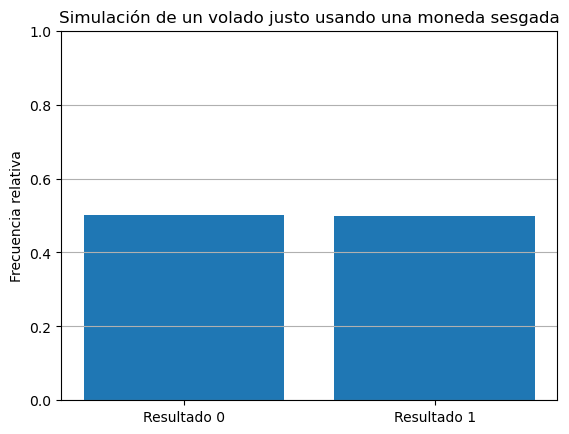

In [3]:
import random
import matplotlib.pyplot as plt

def moneda_sesgada(p):
    return "A" if random.random() < p else "S"

def volado_justo(p):
    while True:
        x = moneda_sesgada(p)
        y = moneda_sesgada(p)

        if x == "A" and y == "S":
            return 0
        elif x == "S" and y == "A":
            return 1

p = 0.8
N = 10000

resultados = [0, 0]

for _ in range(N):
    r = volado_justo(p)
    resultados[r] += 1

frecuencias = [resultados[0] / N, resultados[1] / N]

plt.bar(["Resultado 0", "Resultado 1"], frecuencias)
plt.ylabel("Frecuencia relativa")
plt.title("Simulación de un volado justo usando una moneda sesgada")
plt.ylim(0, 1)
plt.grid(True, axis="y")
plt.show()


### Resumen: 

El mecanismo es:

1) Lanzar dos veces la moneda;
2) Si sale AS, declarar "Resultado A";
3) Si sale SA, declarar "Resultado B";4) Si sale $A A$ o $S S$, repetir.

Funciona porque

$$
P(A S)=p(1-p)=(1-p) p=P(S A),
$$

De modo que ambos resultados útiles son equiprobables. Además, la probabilidad de que un intento sea útil es

$$
2 p(1-p)>0,
$$

Por lo que el proceso termina en tiempo finito con probabilidad 1.